# ==========================================================
# AI-POWERED CUSTOMER RETENTION INTELLIGENCE PLATFORM
#
# PHASE 8
# BUSINESS IMPACT ANALYSIS
#
# NOTEBOOK:
# 04_Business_Impact.ipynb
# ==========================================================

In [1]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)

LIBRARIES IMPORTED SUCCESSFULLY


In [2]:
# ==========================================================
# PROJECT PATH
# ==========================================================

PROJECT_ROOT = os.path.abspath("..")

print(PROJECT_ROOT)

d:\AI-Powered-Customer-Retention-Intelligence-Platform


In [3]:
# ==========================================================
# LOAD RECOMMENDATION DATASET
# ==========================================================

dataset_path = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "customer_retention_recommendations.csv"
)

recommendation_data = pd.read_csv(dataset_path)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print(recommendation_data.head())

DATASET LOADED
                 customer_unique_id  Recency  Frequency  Monetary  \
0  0000366f3b9a7992bf8c76cfdf3221e2      161          1    141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     27.19   
2  0000f46a3911fa3c0805444483337064      586          1     86.22   
3  0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62   
4  0004aac84e0df4da2b147fca70cf8255      337          1    196.89   

   average_review_score preferred_payment_method  average_order_value  \
0                   5.0              credit_card               141.90   
1                   4.0              credit_card                27.19   
2                   3.0              credit_card                86.22   
3                   4.0              credit_card                43.62   
4                   5.0              credit_card               196.89   

   customer_lifetime_value Customer_Risk  churn_label  Risk_Probability  \
0                   141.90        Medium            0   

In [4]:
# ==========================================================
# PRIORITY CUSTOMER ANALYSIS
# ==========================================================

priority_summary = (
    recommendation_data["Priority"]
    .value_counts()
    .reset_index()
)

priority_summary.columns = [
    "Priority",
    "Customer_Count"
]

print("=" * 60)
print("PRIORITY SUMMARY")
print("=" * 60)

print(priority_summary)

PRIORITY SUMMARY
   Priority  Customer_Count
0  Critical           58757
1    Medium           37162
2       Low             177


In [5]:
# ==========================================================
# CAMPAIGN COVERAGE
# ==========================================================

campaign_summary = (
    recommendation_data["Campaign_Type"]
    .value_counts()
    .reset_index()
)

campaign_summary.columns = [
    "Campaign_Type",
    "Customer_Count"
]

print("=" * 60)
print("CAMPAIGN COVERAGE")
print("=" * 60)

print(campaign_summary)

CAMPAIGN COVERAGE
  Campaign_Type  Customer_Count
0     Promotion           35341
1  Reactivation           35171
2       Service           13483
3     Retention           10356
4       Loyalty            1657
5        Growth              88


In [6]:
# ==========================================================
# CUSTOMER VALUE ANALYSIS
# ==========================================================

customer_value_summary = (
    recommendation_data
    .groupby("Customer_Value")["Monetary"]
    .agg(
        Customer_Count="count",
        Average_Spend="mean",
        Total_Revenue="sum"
    )
    .reset_index()
)

print("=" * 60)
print("CUSTOMER VALUE SUMMARY")
print("=" * 60)

print(customer_value_summary)

CUSTOMER VALUE SUMMARY
  Customer_Value  Customer_Count  Average_Spend  Total_Revenue
0     High Value           32032     339.792906    10884246.37
1      Low Value           32032      49.992798     1601369.30
2   Medium Value           32032     109.991772     3523256.45


In [7]:
# ==========================================================
# REVENUE PROTECTION ESTIMATE
# ==========================================================

critical_customers = recommendation_data[
    recommendation_data["Priority"] == "Critical"
]

estimated_revenue_protected = (
    critical_customers["Monetary"].sum() * 0.30
)

print("=" * 60)
print("ESTIMATED REVENUE PROTECTED")
print("=" * 60)

print(f"${estimated_revenue_protected:,.2f}")

ESTIMATED REVENUE PROTECTED
$2,500,604.49


In [8]:
# ==========================================================
# EXECUTIVE KPI SUMMARY
# ==========================================================

executive_summary = pd.DataFrame({

    "Metric":[

        "Total Customers",

        "Critical Customers",

        "Recommendation Types",

        "Campaign Types",

        "Estimated Revenue Protected"

    ],

    "Value":[

        len(recommendation_data),

        len(critical_customers),

        recommendation_data["Recommendation"].nunique(),

        recommendation_data["Campaign_Type"].nunique(),

        round(estimated_revenue_protected,2)

    ]

})

print("=" * 60)
print("EXECUTIVE SUMMARY")
print("=" * 60)

print(executive_summary)

EXECUTIVE SUMMARY
                        Metric       Value
0              Total Customers    96096.00
1           Critical Customers    58757.00
2         Recommendation Types        9.00
3               Campaign Types        6.00
4  Estimated Revenue Protected  2500604.49


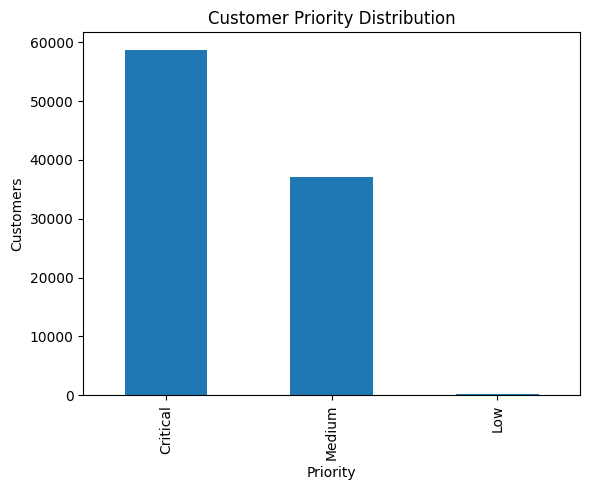

In [9]:
plt.figure(figsize=(6,5))

recommendation_data["Priority"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Priority Distribution")

plt.xlabel("Priority")

plt.ylabel("Customers")

plt.tight_layout()

plt.show()

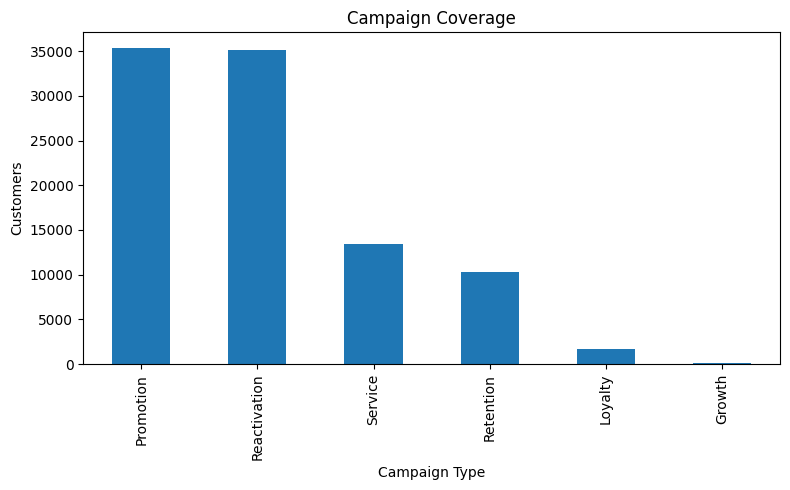

In [10]:
plt.figure(figsize=(8,5))

recommendation_data["Campaign_Type"].value_counts().plot(
    kind="bar"
)

plt.title("Campaign Coverage")

plt.xlabel("Campaign Type")

plt.ylabel("Customers")

plt.tight_layout()

plt.show()

<Figure size 800x500 with 0 Axes>

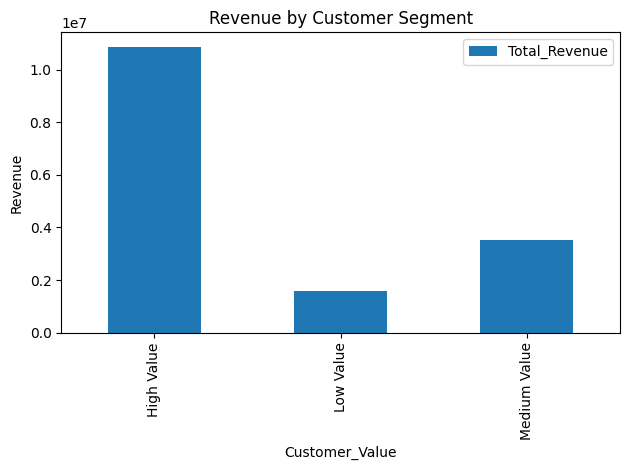

In [11]:
plt.figure(figsize=(8,5))

customer_value_summary.plot(
    x="Customer_Value",
    y="Total_Revenue",
    kind="bar"
)

plt.title("Revenue by Customer Segment")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [12]:
# ==========================================================
# FINAL BUSINESS SUMMARY
# ==========================================================

print("=" * 60)
print("BUSINESS IMPACT SUMMARY")
print("=" * 60)

print(f"""
Total Customers Analysed : {len(recommendation_data)}

Critical Customers       : {len(critical_customers)}

Recommendation Types     : {recommendation_data['Recommendation'].nunique()}

Campaign Types           : {recommendation_data['Campaign_Type'].nunique()}

Estimated Revenue Protected : ${estimated_revenue_protected:,.2f}

Business Objective:
Prioritize high-risk customers,
reduce churn risk,
and improve customer retention through
targeted retention strategies.
""")

BUSINESS IMPACT SUMMARY

Total Customers Analysed : 96096

Critical Customers       : 58757

Recommendation Types     : 9

Campaign Types           : 6

Estimated Revenue Protected : $2,500,604.49

Business Objective:
Prioritize high-risk customers,
reduce churn risk,
and improve customer retention through
targeted retention strategies.

